### <font color='blue'> ANALISE RFV </font>

In [1]:
pip install pymssql

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install pyodbc pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


##### <font color='blue'> Bibliotecas </font>

In [3]:
import datetime as dt

##### <font color='blue'>DataBase (SQL SERVER) *"AdventureWorks2017"* </font>

In [4]:
import pandas as pd
import pyodbc

# String de conexão
conn_str = "Driver={ODBC Driver 17 for SQL Server};Server=localhost\SQLEXPRESS;Database=AdventureWorks2017;Trusted_Connection=yes;"

try:
    # Estabelecendo a conexão
    conexao = pyodbc.connect(conn_str)

    # Tabelas do SQL:
    query_sales_sales_order_detail = "SELECT * FROM Sales.SalesOrderDetail"
    query_sales_sales_order_header = "SELECT * FROM Sales.SalesOrderHeader"
    query_production_product = "SELECT * FROM Production.Product"
    #query_production_product_category = "SELECT * FROM Production.ProductCategory"
    query_sales_customer = "SELECT * FROM Sales.Customer"
    query_vw_fvendas = "SELECT * FROM vw_fVENDAS"
    
# -------------------------------------------------------------------------------------------
    
    # df das tabelas do SQL
    # Lendo os dados da QUERY diretamente para um DataFrame
    df_sales_sales_order_detail = pd.read_sql(query_sales_sales_order_detail, conexao)
    df_sales_sales_order_header = pd.read_sql(query_sales_sales_order_header, conexao)
    df_production_product = pd.read_sql(query_production_product, conexao)
    #df_production_product_category = pd.read_sql(query_production_product_category, conexao)
    df_sales_customer = pd.read_sql(query_sales_customer, conexao)
    df_vw_fvendas = pd.read_sql(query_vw_fvendas, conexao)

# ------------------------------------------------------------------------------------------------

    # Mostra as primeiras 5 linhas
#    print(df_salesvsalesperson.head(2))

except Exception as e:
    print(f"Erro ao conectar ou consultar o banco: {e}")

finally:
    # Sempre feche a conexão para liberar recursos do servidor
    if 'conexao' in locals():
        conexao.close()

C:\Users\olive\AppData\Local\Temp\ipykernel_51848\461479619.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sales_sales_order_detail = pd.read_sql(query_sales_sales_order_detail, conexao)
C:\Users\olive\AppData\Local\Temp\ipykernel_51848\461479619.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sales_sales_order_header = pd.read_sql(query_sales_sales_order_header, conexao)
C:\Users\olive\AppData\Local\Temp\ipykernel_51848\461479619.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_production_product = 

##### <font color='blue'> Backup </font>

In [5]:
df_vw_fvendas_ajustado = df_vw_fvendas

##### <font color='red'> *Formatando* as variaveis do df vw_fvendas</font>

In [6]:
# Formatando variaveis de datas
df_vw_fvendas_ajustado['OrderDate'] = pd.to_datetime(df_vw_fvendas_ajustado['OrderDate'], format='%d/%m/%y')
df_vw_fvendas_ajustado['DueDate'] = pd.to_datetime(df_vw_fvendas_ajustado['DueDate'], format='%d/%m/%y')

##### <font color='red'> Criando df considerando o periodo de 18 meses (a partir de 01/01/2013) </font>

##### <font color='blue'> Backup </font>

In [7]:
# OrdeDate Min 2013-01-01
# OrderDate Max 2014-06-30
df_fvendas = df_vw_fvendas[df_vw_fvendas.OrderDate > '2013-07-01']

In [8]:
# Formatando as variavaies de valores
df_fvendas['TotalDue'] = df_fvendas['TotalDue'].astype(float).round(2)

C:\Users\olive\AppData\Local\Temp\ipykernel_51848\2913784067.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fvendas['TotalDue'] = df_fvendas['TotalDue'].astype(float).round(2)


##### <font color='red'> Criando df com os dados por cliente </font>

In [9]:
# 1.
# Isso evita o uso de lambdas pesados dentro do groupby
df_pedidos_unicos = df_fvendas.drop_duplicates(subset=['SalesOrderID'])

# 2. Data de referência
data_referencia = df_fvendas['OrderDate'].max() + dt.timedelta(days=1) # Data corte = 01/07/2014

# 3. Agrupamento Otimizado
rfv_analise = df_fvendas.groupby('CustomerID').agg({
    'OrderDate': lambda x: (data_referencia - x.max()).days, # Recorrência
    'SalesOrderID': 'nunique'                                # Frequência
}).reset_index()

# 4. Cálculo do Valor (TotalDue) de forma vetorizada
# Somamos o TotalDue apenas dos pedidos únicos por cliente
valor_por_cliente = df_pedidos_unicos.groupby('CustomerID')['TotalDue'].sum().reset_index()

# 5. Merge dos resultados
rfv_analise = pd.merge(rfv_analise, valor_por_cliente, on='CustomerID')

# Renomeando as colunas
rfv_analise.columns = ['CustomerID', 'Recorrência', 'Frequência', 'TotalDue']

# ---------------------------------------------------------------------------------------------------------

# Atribuição de Notas (Quintis)
# Recorrência: Menor é melhor (nota 5 para poucos dias)
rfv_analise['R_Nota'] = pd.qcut(rfv_analise['Recorrência'], 5, labels=[5, 4, 3, 2, 1])

# Frequência e Valor: Maior é melhor (nota 5 para maiores valores/frequência)
rfv_analise['F_Nota'] = pd.qcut(rfv_analise['Frequência'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfv_analise['V_Nota'] = pd.qcut(rfv_analise['TotalDue'], 5, labels=[1, 2, 3, 4, 5])

# Cálculo do Score Final
# Mantendo sua lógica de média entre F e V
rfv_analise['Score_RFV'] = (rfv_analise['R_Nota'].astype(int) + rfv_analise['F_Nota'].astype(int) + rfv_analise['V_Nota'].astype(int))

##### <font color='red'> *Formatando* as variaveis 'R_Nota', 'F_Nota', 'V_Nota', 'Score_RFV' </font>

In [10]:
# Formatando variaveis de datas
rfv_analise['R_Nota'] = rfv_analise['R_Nota'].astype(int)
rfv_analise['F_Nota'] = rfv_analise['F_Nota'].astype(int)
rfv_analise['V_Nota'] = rfv_analise['V_Nota'].astype(int)
rfv_analise['Score_RFV'] = rfv_analise['Score_RFV'].astype(int)

In [11]:
# Criando variavel 'Segmento' com os parametros de classificação 

def classificar_rfv(rfv_analise):
    soma = rfv_analise['Score_RFV']
    r = rfv_analise['Recorrência']  # Nota de Recência individual (1 a 5)
    
    if soma >= 14:
        return '1) Campeões'
    elif 11 <= soma <= 13:
        return '2) Leais'
    elif 9 <= soma <= 10:
        return '3) Potenciais'
    elif 7 <= soma <= 8:
        # Critério de desempate: R alto é cliente Novo, R baixo está Em Risco
        if r >= 3:
            return '4) Novos'
        else:
            return '5) Em Risco'
    elif 5 <= soma <= 6:
        return '6) Hibernando'
    else:
        return '7) Perdidos'

rfv_analise['Segmento'] = rfv_analise.apply(classificar_rfv, axis=1)

#### <font color='red'> LEGENDA
##### <font color='gray'> Recorrência: quantidade de dias da última compra
##### <font color='gray'> Frequência: quantidade de pedidos </font>

##### <font color='red'> Código groupby para calcular a qtd e %Representatividade de clientes por Segmento </font>

In [12]:
# Criando df qtd de clientes por Segmento
groupby_cli_seg = pd.DataFrame(rfv_analise.groupby('Segmento')['Segmento'].value_counts().astype(int).rename('Qtd_Clientes')).reset_index()

# Criando variavel % CLientes
groupby_cli_seg['%Clientes'] = (groupby_cli_seg['Qtd_Clientes'] / groupby_cli_seg['Qtd_Clientes'].sum() * 100).round(1)
groupby_clientes_segmento = groupby_cli_seg.sort_values(by='Qtd_Clientes', ascending=False)
groupby_clientes_segmento.sort_values(by='Segmento')

,Segmento,Qtd_Clientes,%Clientes
0,1) Campeões,1010,5.6
1,2) Leais,4305,23.9
2,3) Potenciais,4614,25.6
3,4) Novos,4784,26.5
4,5) Em Risco,6,0.0
5,6) Hibernando,2611,14.5
6,7) Perdidos,714,4.0


##### <font color='red'> Código groupby para calcular o faturamento e %Representatividade por Segmento </font>

In [13]:
# Criando df faturamento por Segmento
group_faturamento_seg = pd.DataFrame(rfv_analise.groupby('Segmento')['TotalDue'].sum().astype(float).rename('Faturamento')).reset_index()

# Criando variavel % CLientes
group_faturamento_seg['%Faturamento'] = (group_faturamento_seg['Faturamento'] / group_faturamento_seg['Faturamento'].sum() * 100).round(1)
group_faturamento_seg = group_faturamento_seg.sort_values(by='Faturamento', ascending=False)

# Formatando a variavel 'Faturamento'
group_faturamento_seg['Faturamento'] = group_faturamento_seg['Faturamento'].astype(int)
group_faturamento_seg.sort_values(by='Segmento')

,Segmento,Faturamento,%Faturamento
0,1) Campeões,35532040,70.5
1,2) Leais,6348880,12.6
2,3) Potenciais,4472099,8.9
3,4) Novos,3470532,6.9
4,5) Em Risco,358,0.0
5,6) Hibernando,520831,1.0
6,7) Perdidos,24303,0.0


##### <font color='red'> Criando variaveis 'Data última compra' e 'Data primeira compra' no df rfv_analise </font>

In [14]:
# Data primeiro pedido

# 1. Agrupar por cliente e pegar a data minima (primeiro pedido)
dt_primeiro_pedido = df_fvendas.groupby('CustomerID')['OrderDate'].min().reset_index()

# 2. Renomear a coluna para ficar claro no dataframe de destino
dt_primeiro_pedido.columns = ['CustomerID', 'Dt_primeiro_pedido']

# 3. Trazer a informação do df df_fvendas para o dataframe rfv_analise
rfv_analise = rfv_analise.merge(dt_primeiro_pedido, on='CustomerID', how='left')

# ----------------------------------------------------------------------------------------------

# Data último pedido

# 1. Agrupar por cliente e pegar a data máxima (última compra)
df_dt_ultima_compra = df_fvendas.groupby('CustomerID')['OrderDate'].max().reset_index()

# 2. Renomear a coluna para ficar claro no dataframe de destino
df_dt_ultima_compra.columns = ['CustomerID', 'Dt_ult_pedido']

# 3. Trazer a informação do df df_fvendas para o dataframe rfv_analise
rfv_analise = rfv_analise.merge(df_dt_ultima_compra, on='CustomerID', how='left')

##### <font color='red'> Criando variavel 'qtd de meses sem comprar' </font>

In [15]:
rfv_analise['Qtd_meses_scomprar'] = round(rfv_analise['Recorrência'] / 30,1)

##### <font color='red'> Criando variavel 'Parametro Recorrência' </font>

In [16]:
# Criando variavel 'Param_Recor'

# Criando as condições
cond_param_recor = [
    (rfv_analise['Recorrência'] == 0), # 1)  
    (rfv_analise['Recorrência'] <= 30), # 1)                             
    (rfv_analise['Recorrência'] <= 60), # 2)
    (rfv_analise['Recorrência'] <= 90), # 3)
    (rfv_analise['Recorrência'] <= 120), # 4)
    (rfv_analise['Recorrência'] <= 150), # 5)
    (rfv_analise['Recorrência'] <= 180), # 6)
    (rfv_analise['Recorrência'] > 180) # 7)
]

# Criando os rótulos
valores_param_recor = ['1 pedido', '1) 0-30 dias', '2) 30-60 dias', '3) 60-90 dias', '4) 90-120 dias', '5) 120-150 dias', '6) 150-180 dias', '7) +180 dias']

# Criando a variaavel 'Param_Recor' 
import numpy as np
rfv_analise['Param_Recor'] = np.select(cond_param_recor, valores_param_recor, default='x')

##### <font color='red'> Criando variavel Parametro 'Frequencia' </font>

In [17]:
# Criando variavel 'Param_Freq'

# Criando as condições
cond_param_freq = [
    (rfv_analise['Frequência'] == 0), # 1)  
    (rfv_analise['Frequência'] >= 1), # 2)                             
    (rfv_analise['Frequência'] >= 2), # 3)
    (rfv_analise['Frequência'] >= 3), # 4)
    (rfv_analise['Frequência'] >= 4), # 5)
    (rfv_analise['Frequência'] >= 5) # 6)
]

# Criando os rótulos
valores_param_freq = ['1) 0 pedido', '2) 1 pedidos', '3) 2 pedidos', '4) 3 pedidos', '5) 4 pedidos', '6) 5 pedidos']

# Criando a variaavel 'Param_Freq' 
import numpy as np
rfv_analise['Param_Freq'] = np.select(cond_param_freq, valores_param_freq, default='x')

##### <font color='red'> 'Criando variavel Ticket Médio' </font>

In [18]:
import numpy as np
rfv_analise['Ticket_Medio'] = rfv_analise['TotalDue'] / rfv_analise['Frequência']

# Formatando a variavel Ticket Medio
rfv_analise['Ticket_Medio'] = rfv_analise['Ticket_Medio'].astype(float).round(2)

##### <font color='red'> Criando variavel 'Parametro Ticket Médio' </font>

In [19]:
# Criando variavel 'Param_Ticket_M'

# Criando as condições
cond_param_ticket_m = [
    (rfv_analise['Ticket_Medio'] <= 100),                                       
    (rfv_analise['Ticket_Medio'] > 100) & (rfv_analise['Ticket_Medio'] < 500),   
    (rfv_analise['Ticket_Medio'] >= 500) & (rfv_analise['Ticket_Medio'] < 1000), 
    (rfv_analise['Ticket_Medio'] >= 1000) & (rfv_analise['Ticket_Medio'] < 5000),
    (rfv_analise['Ticket_Medio'] >= 5000)                                      
]

# Criando os rótulos
valores_param_ticket_m = ['1) -100', '2) 100|500', '3) 500|1K', '4) 1K|5K', '5) +5K']

# Criando a variaavel 'Param_Freq' 
import numpy as np
rfv_analise['Param_Ticket_M'] = np.select(cond_param_ticket_m, valores_param_ticket_m, default='x')

##### <font color='red'> Código groupby para calcular a qtd de clientes e '%Representatividade por Parametro Ticket Médio' </font>

In [20]:
# Criando df qtd de clientes por Param_Ticket_M
groupby_clientes_ticket_m = pd.DataFrame(rfv_analise.groupby('Param_Ticket_M')['Param_Ticket_M'].value_counts().astype(int).rename('Qtd_Clientes')).reset_index()

# Criando variavel % CLientes
groupby_clientes_ticket_m['%Clientes'] = (groupby_clientes_ticket_m['Qtd_Clientes'] / groupby_clientes_ticket_m['Qtd_Clientes'].sum() * 100).round(1)
groupby_clientes_ticket_m = groupby_clientes_ticket_m.sort_values(by='Qtd_Clientes', ascending=False)
groupby_clientes_ticket_m.sort_values(by='Param_Ticket_M')

,Param_Ticket_M,Qtd_Clientes,%Clientes
0,1) -100,8329,46.2
1,2) 100|500,1045,5.8
2,3) 500|1K,2603,14.4
3,4) 1K|5K,5809,32.2
4,5) +5K,258,1.4


##### <font color='red'> Criando variavel 'Score_Geral' </font>

In [21]:
rfv_analise['Score_Geral'] = rfv_analise['R_Nota'] + rfv_analise['V_Nota']

In [22]:
# Groupby Ticket Médio por Segmento
ticket_medio_seg = rfv_analise.groupby('Segmento').agg({
                                'Ticket_Medio':'mean'})

#### <font color='green'> CÓDIGO DO GRÁFICO: MAPA DE CALOR RFV: DISTRIBUIÇÃO PERCENTUAL POR SEGMENTO </font>

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

def graf_heatmap_rfv(df_rfv):
    """
    Gera o mapa de calor RFV padronizado a partir de um DataFrame de análise.
    """
    # 1. Cálculos dos dados
    counts = df_rfv.pivot_table(index='V_Nota', columns='R_Nota', values='CustomerID', aggfunc='count', fill_value=0)
    counts = counts.reindex(index=range(1, 6), columns=range(1, 6), fill_value=0)

    total_clientes = len(df_rfv)
    percent_map_original = (counts / total_clientes) * 100

    # 2. Mapeamento dos segmentos
    segment_map = df_rfv.groupby(['V_Nota', 'R_Nota'])['Segmento'].agg(lambda x: x.mode()[0] if not x.empty else "").unstack()
    segment_map = segment_map.reindex(index=range(1, 6), columns=range(1, 6), fill_value="")

    # 3. Cores e Segmentos
    ordem_segmentos = ['1) Campeões', '2) Leais', '3) Potenciais', '4) Novos', '5) Em Risco', '6) Hibernando', '7) Perdidos']
    cores_customizadas = ['#2E7D32', '#4CAF50', '#8BC34A', '#FFEB3B', '#FF9800', '#FF5722', '#D32F2F']
    custom_cmap = ListedColormap(cores_customizadas)
    segmento_peso = {seg: idx for idx, seg in enumerate(ordem_segmentos)}

    # 4. Construção das matrizes
    color_map = np.zeros((5, 5))
    annot_labels = np.empty((5, 5), dtype=object)

    for i, v_nota in enumerate(range(1, 6)):
        for j, r_nota in enumerate(range(1, 6)):
            segmento = segment_map.loc[v_nota, r_nota]
            percentual = percent_map_original.loc[v_nota, r_nota]
            
            if segmento in segmento_peso:
                color_map[i, j] = segmento_peso[segmento]
                annot_labels[i, j] = f"{segmento}\n{percentual:.1f}%"
            else:
                color_map[i, j] = np.nan
                annot_labels[i, j] = ""

    df_color_map = pd.DataFrame(color_map, index=range(1, 6), columns=range(1, 6))
    mask = df_color_map.isna()

    # 5. Configuração Visual do Gráfico
    plt.figure(figsize=(14, 10))
    sns.heatmap(df_color_map, 
                annot=annot_labels, 
                fmt="", 
                cmap=custom_cmap, 
                mask=mask,
                vmin=0, 
                vmax=len(ordem_segmentos)-1,
                linewidths=1.5,
                linecolor='white',
                cbar=False)

    plt.gca().invert_yaxis()
    plt.title('MAPA DE CALOR RFV: DISTRIBUIÇÃO PERCENTUAL POR SEGMENTO', fontsize=16, pad=20, fontweight='bold')
    plt.xlabel('Nota de Recência (Tempo de compra)', fontsize=12, labelpad=10)
    plt.ylabel('Nota de Valor (Gasto cliente)', fontsize=12, labelpad=10)
    plt.tight_layout()
    
    # Exibe o gráfico
    plt.show()

#### <font color='GREEN'> CÓDIGO DO GRÁFICO: DISTRIBUIÇÃO PERCENTUAL DE CLIENTES POR SEGMENTO </font>

In [ ]:
import plotly.express as px

df_cli_seg = pd.DataFrame(groupby_clientes_segmento)

df_cli_seg = df_cli_seg.sort_values(by='Segmento', ascending=False)

# 1. Criando o Gráfico de Barras Horizontais
graf_segmento_cliente = px.bar(
    df_cli_seg, 
    x='%Clientes', 
    y='Segmento',
    orientation='h', # Define o gráfico como horizontal
    title='<b>DISTRIBUIÇÃO PERCENTUAL DE CLIENTES POR SEGMENTO</b>',
    text_auto='.1f', # Mostra o valor nas barras com 1 casa decimal automaticamente
    color='%Clientes', # Gradiente de cor baseado no percentual
    color_continuous_scale='Blues' # Escala de cores elegante
)

# 2. Ajustando a posição do texto e formatação
# 'outside' coloca o percentual logo após o fim da barra, garantindo leitura perfeita
graf_segmento_cliente.update_traces(
    textposition='outside', 
    cliponaxis=False,
    texttemplate="<b>%{x:.1f}%</b>" # Formata o texto final com o símbolo de %
)

# 3. Ajustes de Layout (Removendo poluidores visuais e títulos redundantes dos eixos)
graf_segmento_cliente.update_layout(
    xaxis_title='Percentual (% Clientes)',
    yaxis_title='Segmento',
    coloraxis_showscale=False, # Oculta a barra lateral de legenda de cor
    height=500, # Altura ideal para dar espaço entre as barras dos segmentos
    margin=dict(r=50) # Dá um pequeno espaço na borda direita para o texto não cortar
)

# 4. Renderizar o gráfico na tela/dashboard
graf_segmento_cliente.show()

#### <font color='green'> CÓDIGO DO GRÁFICO: DISTRIBUIÇÃO PERCENTUAL DO FATURAMENTO POR SEGMENTO </font>

In [ ]:
import plotly.express as px

df_fat_seg = pd.DataFrame(group_faturamento_seg)

df_fat_seg = df_fat_seg.sort_values(by='Segmento', ascending=False)

# 1. Criando o Gráfico de Barras Horizontais
graf_segmento_faturamento = px.bar(
    df_fat_seg, 
    x='%Faturamento', 
    y='Segmento',
    orientation='h', # Define o gráfico como horizontal
    title='<b>DISTRIBUIÇÃO PERCENTUAL DO FATURAMENTO POR SEGMENTO</b>',
    text_auto='.1f', # Mostra o valor nas barras com 1 casa decimal automaticamente
    color='%Faturamento', # Gradiente de cor baseado no percentual
    color_continuous_scale='Reds' # Escala de cores elegante
)

# 2. Ajustando a posição do texto e formatação
# 'outside' coloca o percentual logo após o fim da barra, garantindo leitura perfeita
graf_segmento_faturamento.update_traces(
    textposition='outside', 
    cliponaxis=False,
    texttemplate="<b>%{x:.1f}%</b>" # Formata o texto final com o símbolo de %
)

# 3. Ajustes de Layout (Removendo poluidores visuais e títulos redundantes dos eixos)
graf_segmento_faturamento.update_layout(
    xaxis_title='Percentual (%Faturamento)',
    yaxis_title='Segmento',
    coloraxis_showscale=False, # Oculta a barra lateral de legenda de cor
    height=500, # Altura ideal para dar espaço entre as barras dos segmentos
    margin=dict(r=50) # Dá um pequeno espaço na borda direita para o texto não cortar
)

# 4. Renderizar o gráfico na tela/dashboard
graf_segmento_faturamento.show()

#### <font color='red'> Variavel 'Tendencia de Segmento' </font>

In [26]:
# Vamos calcular a média de Score de cada segmento para ver quem está acima ou abaixo da média do próprio grupo

# 1. Calcula a média do Score para cada um dos 11 segmentos
rfv_analise['Media_Segmento'] = rfv_analise.groupby('Segmento')['Score_RFV'].transform('mean')

# 2. Cria as condições
# Se o score do cliente for muito maior que a média do grupo dele, ele está "Próximo de Subir"
# Se for muito menor, ele está "Em Alerta (Risco de Queda)"
condicoes = [
    (rfv_analise['Score_RFV'] > rfv_analise['Media_Segmento'] * 1.08), # 5% acima da média do grupo
    (rfv_analise['Score_RFV'] < rfv_analise['Media_Segmento'] * 0.9), # 10% abaixo da média do grupo
]

valores = ['Crescendo', 'Declinando']

# 3. Cria a nova coluna desejada
rfv_analise['Tendencia_Segmento'] = np.select(condicoes, valores, default='Estável')

# Removendo a coluna auxiliar de média para o df ficar limpo
rfv_analise = rfv_analise.drop(columns=['Media_Segmento'])

#### <font color='green'> CÓDIGO DO GRÁFICO: DISTRIBUIÇÃO PERCENTUAL DE TENDÊNCIAS POR SEGMENTO </font>

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def graf_tendencia_cli(rfv_analise):
    """
    Gera um gráfico de barras horizontais empilhadas mostrando a 
    distribuição percentual de tendência para cada segmento RFV.
    """
    # 1. Matriz percentual cruzada (Segmento vs Tendência)
    df_porcentagem = pd.crosstab(
        rfv_analise['Segmento'], 
        rfv_analise['Tendencia_Segmento'], 
        normalize='index'
    ) * 100

    # Reordenando os segmentos (Melhores para os piores)
    ordem_segmentos = ['1) Campeões', '2) Leais', '3) Potenciais', '4) Novos', '5) Em Risco', '6) Hibernando', '7) Perdidos']
    ordem_filtrada = [seg for seg in ordem_segmentos if seg in df_porcentagem.index]
    df_porcentagem = df_porcentagem.reindex(ordem_filtrada)

    # 2. Configuração do estilo visual
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(12, 7))

    # Cores estratégicas para as tendências
    cores = {
        'Crescendo': '#2ecc71',   # Verde
        'Estável': '#3498db',     # Azul
        'Declinando': '#e74c3c'    # Vermelho
    }

    # 3. Plotagem das barras horizontais empilhadas
    df_porcentagem.plot(
        kind='barh', 
        stacked=True, 
        ax=ax, 
        color=[cores.get(col, '#95a5a6') for col in df_porcentagem.columns],
        width=0.7
    )

    # 4. Rótulos de porcentagem dentro das barras
    for p in ax.patches:
        width = p.get_width()
        if width > 5: # Só mostra se a fatia for maior que 5%
            ax.text(
                p.get_x() + width / 2, 
                p.get_y() + p.get_height() / 2, 
                f'{width:.1f}%', 
                ha='center', 
                va='center', 
                color='white', 
                fontweight='bold',
                fontsize=10
            )

    # 5. Ajustes estéticos finais
    ax.set_title('DISTRIBUIÇÃO PERCENTUAL DE TENDÊNCIAS POR SEGMENTO', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Percentual de Clientes (%)', fontsize=12, labelpad=10)
    ax.set_ylabel('Segmento RFV', fontsize=12, labelpad=10)
    ax.set_xlim(0, 100)

    # Mantém os Campeões no topo
    ax.invert_yaxis()

    # Legenda externa
    ax.legend(title='Tendência do Cliente', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

    plt.tight_layout()
    plt.show()

##### <font color='red'> Código Groupby 'Media Score RFV' por Segmento </font>

In [28]:
groupby_media_scorerfv = rfv_analise.groupby('Segmento').agg(
                        Media_Score_RFV=('Score_RFV','mean')
).reset_index()

groupby_media_scorerfv['Media_Score_RFV'] = groupby_media_scorerfv['Media_Score_RFV'].round(1)

In [ ]:
import plotly.express as px

# 1. Garantindo que o DataFrame use o seu agrupamento corrigido
df_media_score_seg = pd.DataFrame(groupby_media_scorerfv)

# 2. Ordenando do MAIOR para o MENOR valor para o gráfico vertical
df_media_score_seg = df_media_score_seg.sort_values(by='Segmento', ascending=True)

# 3. Criando o Gráfico de Barras Verticais
graf_media_score_cli = px.bar(
    df_media_score_seg, 
    x='Segmento',             # Eixo X com os nomes dos segmentos
    y='Media_Score_RFV',        # Eixo Y com a média do score (valores puros)
    title='<b>MÉDIA DE SCORE RFV POR SEGMENTO</b>',
    text_auto='.1f',           # Exibe o valor em cima da barra com 1 casa decimal
    color='Media_Score_RFV',    # Aplica o gradiente baseado no valor
    color_continuous_scale='Blues'
)

# 4. Ajustando a posição do texto (em cima das barras)
graf_media_score_cli.update_traces(
    textposition='outside', 
    cliponaxis=False,
    texttemplate="<b>%{y:.1f}</b>" # Exibe apenas o número puro, sem o "%"
)

# 5. Ajustes de Layout e remoção de poluidores visuais
graf_media_score_cli.update_layout(
    xaxis_title='Segmento',
    yaxis_title='Média de Score_RFV',
    coloraxis_showscale=False,  # Oculta a barra de escala lateral
    height=500
)

# 6. Renderizar o gráfico
graf_media_score_cli.show()

#### <font color='red'> ========================================================================================== ' </font>

#### <font color='blue'>ANÁLISE RFV: IDENTIFICANDO OPORTUNIDADES E COMBATENDO O CHURN</font>

In [52]:
from IPython.display import display, Markdown
display(Markdown("""

#### OBJETIVO:
    
 - **Transformar esses números em ações estratégicas que gerem receita ou evitem a perda de clientes Churn.** 
 
 **Churn:** *É a métrica que mede a taxa de cancelamento ou evasão de clientes em uma empresa, ela indica quantos clientes deixaram de comprar.*
 
   ---------------------------------------------------------------------------------------------------------------------
- **RESUMO POR SEGMENTO:**

- **🏆1. Campeões:**

  **👥Quantidade clientes:** *1K (5,6%)*
 
  **💰Faturamento:** *R$35.5M (70,5%)*

  **💲Ticket Médio:** *R$10.9K (média)*

  **RFV: Recorrência:** *73 dias (média de dias para comprar)* | **Frequência:** *3 pedidos (média de pedidos)* | **Score_RFV:** *14 até 15*
  
   --------------------------------------------------------------------------------------------------------------------- 
- **🤝2. Leais:**

  **👥Quantidade clientes:** *4.3K (23,9%)*

  **💰Faturamento:** *R$6.3M (12,6%)*
  
  **💲Ticket Médio:** *R$1.2K (média)*

  **RFV: Recorrência:** *94 dias (média de dias para comprar)* | **Frequência:** *1.5 pedido (média de pedidos)* | **Score_RFV:** *11 até 13*
  
   ---------------------------------------------------------------------------------------------------------------------
- **🚀3. Potenciais:** 

  **👥Quantidade clientes:** *4.6K (25,6%)*

  **💰Faturamento:** *R$4.4M (8,9%)*
 
  **💲Ticket Médio:** *R$963 (média)*

  **RFV: Recorrência:** *143 dias (média de dias para comprar)* | **Frequência:** *1 pedido (média de pedidos)* | **Score_RFV:** *9 até 10*
  
   ---------------------------------------------------------------------------------------------------------------------
- **🆕4. Novos:**

  **👥Quantidade clientes:** *4.7K (26,5%)*

  **💰Faturamento:** *R$3.4M (6,9%)*
 
  **💲Ticket Médio:** *R$725 (média)*

  **RFV: Recorrência:** *205 dias (média de dias para comprar)* | **Frequência:** *1 pedido (média de pedidos)* | **Score_RFV:** *7 até 8* (Recorrência alta)

   ---------------------------------------------------------------------------------------------------------------------
- **🚨5. Em Risco:**

  **👥Quantidade clientes:** *6 (0%)*

  **💰Faturamento:** *R$358 (0%)*
 
  **💲Ticket Médio:** *R$59 (média)*

  **RFV: Recorrência:** *1 dia (média de dias para comprar)* | **Frequência:** *1 pedido (média de pedidos)* | **Score_RFV:** *7 até 8* (Recorrência baixa)

   ---------------------------------------------------------------------------------------------------------------------
- **😴6. Hibernando:**

  **👥Quantidade clientes:** *2.6K (14,5%)*

  **💰Faturamento:** *R$520.8k (1,0%)*
 
  **💲Ticket Médio:** *R$200 (média)*

  **RFV: Recorrência:** *259 dias (média de dias para comprar)* | **Frequência:** *1 pedido (média de pedidos)* | **Score_RFV:** *5 até 6*  

   ---------------------------------------------------------------------------------------------------------------------   
- **☠️7. Perdidos:**

  **👥Quantidade clientes:** *714 (4%)*

  **💰Faturamento:** *R$24.3K (0%)*
 
  **💲Ticket Médio:** *R$34 (média)*

  **RFV: Recorrência:** *299 dias (média de dias para comprar)* | **Frequência:** *1 pedido (média de pedidos)* | **Score_RFV:** *3 até 4*  
"""))



#### OBJETIVO:

 - **Transformar esses números em ações estratégicas que gerem receita ou evitem a perda de clientes Churn.** 

 **Churn:** *É a métrica que mede a taxa de cancelamento ou evasão de clientes em uma empresa, ela indica quantos clientes deixaram de comprar.*

   ---------------------------------------------------------------------------------------------------------------------
- **RESUMO POR SEGMENTO:**

- **🏆1. Campeões:**

  **👥Quantidade clientes:** *1K (5,6%)*

  **💰Faturamento:** *R$35.5M (70,5%)*

  **💲Ticket Médio:** *R$10.9K (média)*

  **RFV: Recorrência:** *73 dias (média de dias para comprar)* | **Frequência:** *3 pedidos (média de pedidos)* | **Score_RFV:** *14 até 15*

   --------------------------------------------------------------------------------------------------------------------- 
- **🤝2. Leais:**

  **👥Quantidade clientes:** *4.3K (23,9%)*

  **💰Faturamento:** *R$6.3M (12,6%)*

  **💲Ticket Médio:** *R$1.2K (média)*

  **RFV: Recorrência:** *94 dias (média de dias para comprar)* | **Frequência:** *1.5 pedido (média de pedidos)* | **Score_RFV:** *11 até 13*

   ---------------------------------------------------------------------------------------------------------------------
- **🚀3. Potenciais:** 

  **👥Quantidade clientes:** *4.6K (25,6%)*

  **💰Faturamento:** *R$4.4M (8,9%)*

  **💲Ticket Médio:** *R$963 (média)*

  **RFV: Recorrência:** *143 dias (média de dias para comprar)* | **Frequência:** *1 pedido (média de pedidos)* | **Score_RFV:** *9 até 10*

   ---------------------------------------------------------------------------------------------------------------------
- **🆕4. Novos:**

  **👥Quantidade clientes:** *4.7K (26,5%)*

  **💰Faturamento:** *R$3.4M (6,9%)*

  **💲Ticket Médio:** *R$725 (média)*

  **RFV: Recorrência:** *205 dias (média de dias para comprar)* | **Frequência:** *1 pedido (média de pedidos)* | **Score_RFV:** *7 até 8* (Recorrência alta)

   ---------------------------------------------------------------------------------------------------------------------
- **🚨5. Em Risco:**

  **👥Quantidade clientes:** *6 (0%)*

  **💰Faturamento:** *R$358 (0%)*

  **💲Ticket Médio:** *R$59 (média)*

  **RFV: Recorrência:** *1 dia (média de dias para comprar)* | **Frequência:** *1 pedido (média de pedidos)* | **Score_RFV:** *7 até 8* (Recorrência baixa)

   ---------------------------------------------------------------------------------------------------------------------
- **😴6. Hibernando:**

  **👥Quantidade clientes:** *2.6K (14,5%)*

  **💰Faturamento:** *R$520.8k (1,0%)*

  **💲Ticket Médio:** *R$200 (média)*

  **RFV: Recorrência:** *259 dias (média de dias para comprar)* | **Frequência:** *1 pedido (média de pedidos)* | **Score_RFV:** *5 até 6*  

   ---------------------------------------------------------------------------------------------------------------------   
- **☠️7. Perdidos:**

  **👥Quantidade clientes:** *714 (4%)*

  **💰Faturamento:** *R$24.3K (0%)*

  **💲Ticket Médio:** *R$34 (média)*

  **RFV: Recorrência:** *299 dias (média de dias para comprar)* | **Frequência:** *1 pedido (média de pedidos)* | **Score_RFV:** *3 até 4*  


#### <font color='blue'> 🟩🟨🟧🟥1. ANÁLISE DA DISTRIBUIÇÂO E DENSIDADE DA BASE DE CLIENTES POR SEGMENTO </font>

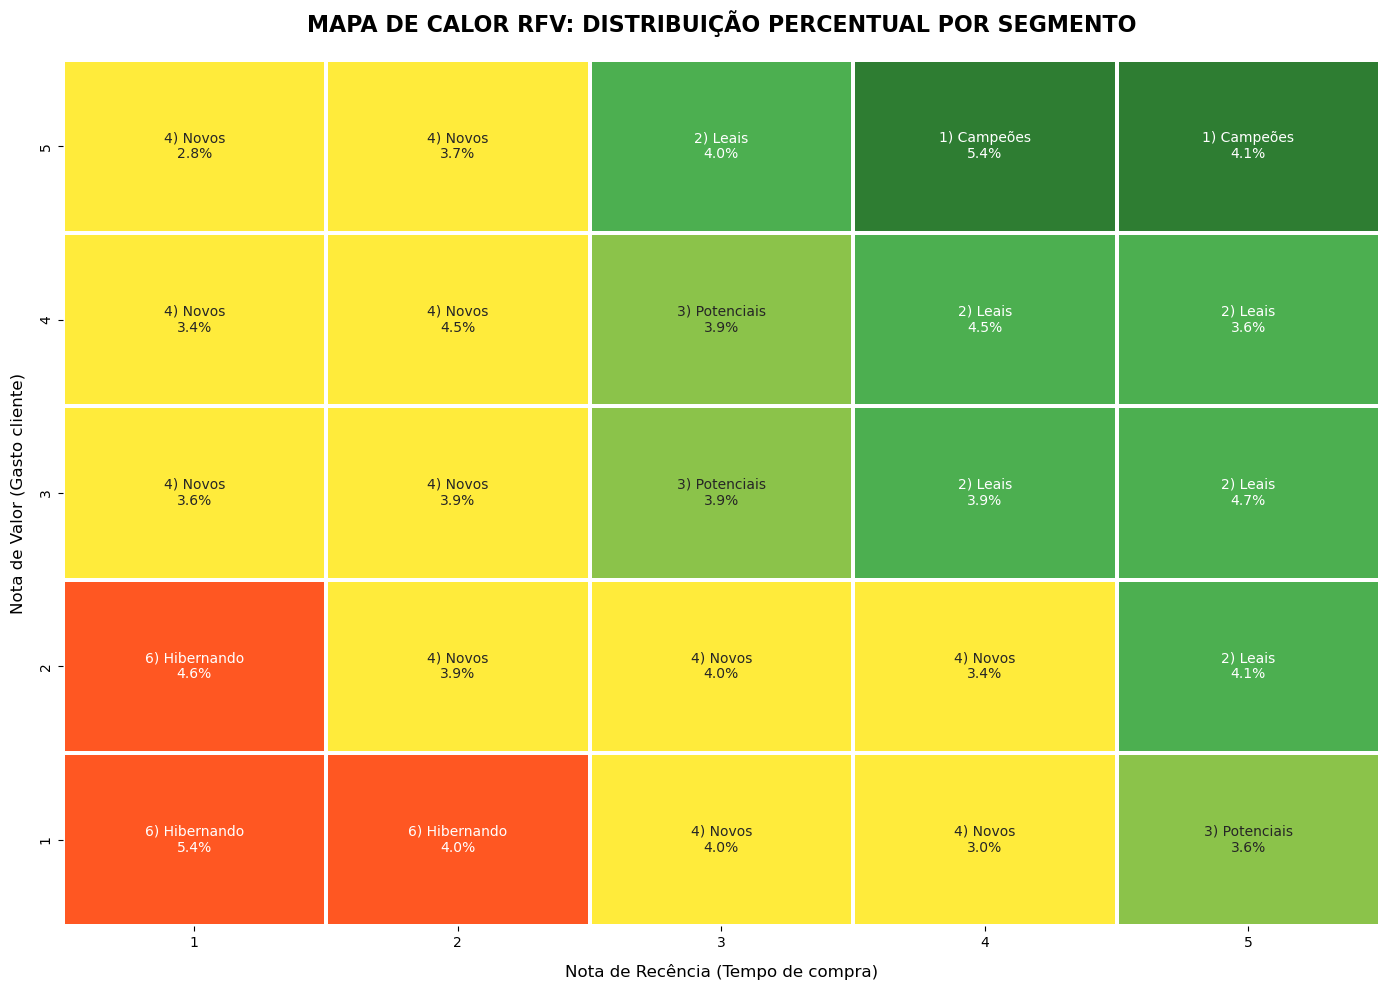

In [31]:
graf_heatmap_rfv(rfv_analise)

In [46]:
from IPython.display import display, Markdown
display(Markdown("""
#### ANÁLISE DO GRÁFICO: "🟩🟨🟧🟥1. ANÁLISE DA DISTRIBUIÇÂO E DENSIDADE DA BASE DE CLIENTES POR SEGMENTO"

- **🟢1. O Bloco Verde Escuro (O Topo do Faturamento):**

  **📈O que o gráfico mostra:** *No topo direito (coordenadas de maior Valor e Recência), você verá as células de "Campeões" divididas (ex: 5,4% em uma célula e 4,1% na outra). 
  Todo esse bloco compartilha o mesmo tom de verde escuro.*

  ***➔ 💡Insight:*** *A cor verde escura isolada no topo mostra visualmente onde está o "ouro" da empresa. 
  Embora o volume de clientes ali pareça fragmentado em pequenos percentuais por célula, 
  a cor verde deixa claro para a diretoria que este é um bloco único e consolidado de alto valor que precisa ser blindado.*
  
   ---------------------------------------------------------------------------------------------------------------------
 - **🟢🟡2. Verde Claro e Amarela:**

   **📈O que o gráfico mostra:** *Uma grande massa de dados concentrada nas colunas da direita (Recência 4 e 5), colorida em tons de Verde Claro (Leais) e Amarelo (Novos/Potenciais).*

   ***➔ 💡Insight:*** *Este é o insight visual mais poderoso do seu gráfico. A predominância de cores claras e quentes do lado direito prova que a empresa tem uma excelente "força de atração". 
   Há uma barreira fechada de clientes que compraram recentemente.*

   ***➔ 🔑Direcionamento:*** *O desafio que o gráfico mostra é claramente o vertical: o seu time de CRM precisa fazer essa "faixa amarela" subir no eixo Y (Valor), transformando esses clientes novos em blocos verdes ("Leais" e "Campeões").*
   
   ---------------------------------------------------------------------------------------------------------------------
 - **🟡🔴3. Laranja ao Vermelho:**
 
   **📈O que o gráfico mostra:** *Na esquerda do gráfico (Recência menor, de 3 para 1), as cores mudam nitidamente para Laranja (Em "Risco"/"Hibernando") e Vermelho ("Perdidos").*

   ***➔ 💡Insight:*** *O gráfico desenha perfeitamente o "sinal de envelhecimento" do seu cliente. 
     O ponto positivo é que o canto superior esquerdo (Alto Valor e Baixa Recência) não está muito carregado em percentuais. 
     Isso significa que você não está sofrendo com uma perda severa de clientes que gastavam muito e sumiram; quem está ficando vermelho são, majoritariamente, clientes que já tinham notas baixas de valor.*

"""))


#### ANÁLISE DO GRÁFICO: "🟩🟨🟧🟥1. ANÁLISE DA DISTRIBUIÇÂO E DENSIDADE DA BASE DE CLIENTES POR SEGMENTO"

- **🟢1. O Bloco Verde Escuro (O Topo do Faturamento):**

  **📈O que o gráfico mostra:** *No topo direito (coordenadas de maior Valor e Recência), você verá as células de "Campeões" divididas (ex: 5,4% em uma célula e 4,1% na outra). 
  Todo esse bloco compartilha o mesmo tom de verde escuro.*

  ***➔ 💡Insight:*** *A cor verde escura isolada no topo mostra visualmente onde está o "ouro" da empresa. 
  Embora o volume de clientes ali pareça fragmentado em pequenos percentuais por célula, 
  a cor verde deixa claro para a diretoria que este é um bloco único e consolidado de alto valor que precisa ser blindado.*

   ---------------------------------------------------------------------------------------------------------------------
 - **🟢🟡2. Verde Claro e Amarela:**

   **📈O que o gráfico mostra:** *Uma grande massa de dados concentrada nas colunas da direita (Recência 4 e 5), colorida em tons de Verde Claro (Leais) e Amarelo (Novos/Potenciais).*

   ***➔ 💡Insight:*** *Este é o insight visual mais poderoso do seu gráfico. A predominância de cores claras e quentes do lado direito prova que a empresa tem uma excelente "força de atração". 
   Há uma barreira fechada de clientes que compraram recentemente.*

   ***➔ 🔑Direcionamento:*** *O desafio que o gráfico mostra é claramente o vertical: o seu time de CRM precisa fazer essa "faixa amarela" subir no eixo Y (Valor), transformando esses clientes novos em blocos verdes ("Leais" e "Campeões").*

   ---------------------------------------------------------------------------------------------------------------------
 - **🟡🔴3. Laranja ao Vermelho:**

   **📈O que o gráfico mostra:** *Na esquerda do gráfico (Recência menor, de 3 para 1), as cores mudam nitidamente para Laranja (Em "Risco"/"Hibernando") e Vermelho ("Perdidos").*

   ***➔ 💡Insight:*** *O gráfico desenha perfeitamente o "sinal de envelhecimento" do seu cliente. 
     O ponto positivo é que o canto superior esquerdo (Alto Valor e Baixa Recência) não está muito carregado em percentuais. 
     Isso significa que você não está sofrendo com uma perda severa de clientes que gastavam muito e sumiram; quem está ficando vermelho são, majoritariamente, clientes que já tinham notas baixas de valor.*



#### <font color='blue'>👥2. ANÁLISE SOBRE A COMPOSIÇÃO DA CARTEIRA DE CLIENTES POR PERFIL RFV</font>

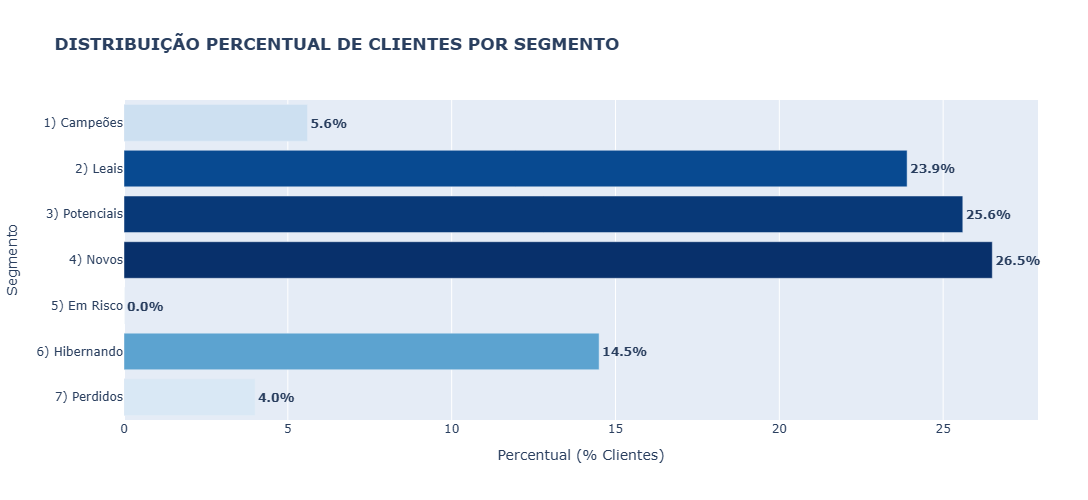

In [33]:
graf_segmento_cliente

In [47]:
from IPython.display import display, Markdown
display(Markdown("""
#### ANÁLISE DO GRÁFICO: "👥2. ANÁLISE SOBRE A COMPOSIÇÃO DA CARTEIRA DE CLIENTES POR PERFIL RFV"

- **💰1. O Faturamento está saudável, mas exige cuidado:**

  **🏆"Campeões" (5,6%) + "Leais" (23,9%):** *Juntos, eles representam 29,5% da sua base. No varejo e em modelos de negócios tradicionais, 
  é muito comum que esse grupo (cerca de 30% dos clientes) seja responsável por 60% a 80% do seu faturamento.*

  ***➔ 💡Insight:*** *A proporção de clientes Leais é excelente (quase um quarto da base). 
  Isso mostra que seu produto ou serviço entrega valor e gera recorrência. 
  O desafio aqui é entender o que falta para transformar parte desses "Leais" em "Campeões" (aumentar o ticket médio ou a frequência), 
  não mexa no preço, foque na experiência.*
  
   ---------------------------------------------------------------------------------------------------------------------
- **🎯2. "A Oportunidade" (O Maior Potencial de Crescimento):**

  ***"Potenciais" (25,6%) + "Novos" (26,5%):*** *Esta é a maior mina de ouro do seu gráfico, somando 52,1% — mais da metade de todos os seus clientes!
  Boa performance em atrair clientes, mas eles estão travados na "zona de conforto" (compram pouco e geram pouca receita).*

  ***➔ 💡Insight:*** *Sua empresa está conseguindo atrair muitas pessoas (alta taxa de novos clientes). 
  Porém, mais de 50% da sua base ainda não se consolidou. Se esses clientes comprarem apenas uma vez e sumirem, o custo de aquisição (CAC) vai ficar alto.*

  ***➔ 🛠Ação:*** *O foco total do seu time de marketing/CRM deve ser a jornada de ativação. É preciso criar réguas de comunicação e ofertas personalizadas
  para fazer esses "Novos" e "Potenciais" realizarem a segunda e a terceira compra, movendo-os para o grupo de Leais.*
  
   ---------------------------------------------------------------------------------------------------------------------
- **⚠️3. Zona de Alerta e Recuperação:**

  ***"Hibernando" (14,5%) + "Perdidos" (4,0%):*** *Somam 18,5% da base.*

  ***➔ 💡Insight:*** *Ter 14,5% de clientes hibernando (compraram há algum tempo, mas sumiram) é um sinal de alerta, 
  mas também uma oportunidade. Como eles já conhecem sua marca, reativá-los costuma ser mais barato do que trazer um cliente do zero. 
  Já os Perdidos (4,0%) estão em um nível perfeitamente aceitável e saudável (um churn controlado).*

  ***➔ 🚨"Em Risco" (0,01%):*** *Este número está virtualmente zerado. Isso significa que quase nenhum cliente que costumava ser muito ativo está no limite de sumir agora — ou eles já caíram direto para "Hibernando"/"Perdidos", ou a sua régua de corte para "Em Risco" pode estar muito estreita no código.*

"""))


#### ANÁLISE DO GRÁFICO: "👥2. ANÁLISE SOBRE A COMPOSIÇÃO DA CARTEIRA DE CLIENTES POR PERFIL RFV"

- **💰1. O Faturamento está saudável, mas exige cuidado:**

  **🏆"Campeões" (5,6%) + "Leais" (23,9%):** *Juntos, eles representam 29,5% da sua base. No varejo e em modelos de negócios tradicionais, 
  é muito comum que esse grupo (cerca de 30% dos clientes) seja responsável por 60% a 80% do seu faturamento.*

  ***➔ 💡Insight:*** *A proporção de clientes Leais é excelente (quase um quarto da base). 
  Isso mostra que seu produto ou serviço entrega valor e gera recorrência. 
  O desafio aqui é entender o que falta para transformar parte desses "Leais" em "Campeões" (aumentar o ticket médio ou a frequência), 
  não mexa no preço, foque na experiência.*

   ---------------------------------------------------------------------------------------------------------------------
- **🎯2. "A Oportunidade" (O Maior Potencial de Crescimento):**

  ***"Potenciais" (25,6%) + "Novos" (26,5%):*** *Esta é a maior mina de ouro do seu gráfico, somando 52,1% — mais da metade de todos os seus clientes!
  Boa performance em atrair clientes, mas eles estão travados na "zona de conforto" (compram pouco e geram pouca receita).*

  ***➔ 💡Insight:*** *Sua empresa está conseguindo atrair muitas pessoas (alta taxa de novos clientes). 
  Porém, mais de 50% da sua base ainda não se consolidou. Se esses clientes comprarem apenas uma vez e sumirem, o custo de aquisição (CAC) vai ficar alto.*

  ***➔ 🛠Ação:*** *O foco total do seu time de marketing/CRM deve ser a jornada de ativação. É preciso criar réguas de comunicação e ofertas personalizadas
  para fazer esses "Novos" e "Potenciais" realizarem a segunda e a terceira compra, movendo-os para o grupo de Leais.*

   ---------------------------------------------------------------------------------------------------------------------
- **⚠️3. Zona de Alerta e Recuperação:**

  ***"Hibernando" (14,5%) + "Perdidos" (4,0%):*** *Somam 18,5% da base.*

  ***➔ 💡Insight:*** *Ter 14,5% de clientes hibernando (compraram há algum tempo, mas sumiram) é um sinal de alerta, 
  mas também uma oportunidade. Como eles já conhecem sua marca, reativá-los costuma ser mais barato do que trazer um cliente do zero. 
  Já os Perdidos (4,0%) estão em um nível perfeitamente aceitável e saudável (um churn controlado).*

  ***➔ 🚨"Em Risco" (0,01%):*** *Este número está virtualmente zerado. Isso significa que quase nenhum cliente que costumava ser muito ativo está no limite de sumir agora — ou eles já caíram direto para "Hibernando"/"Perdidos", ou a sua régua de corte para "Em Risco" pode estar muito estreita no código.*



#### <font color='blue'>💰3. ANÁLISE DA PARTICIPAÇÂO DA RECEITA POR PERFIL DE CLIENTE (SEGMENTO RFV)  </font>

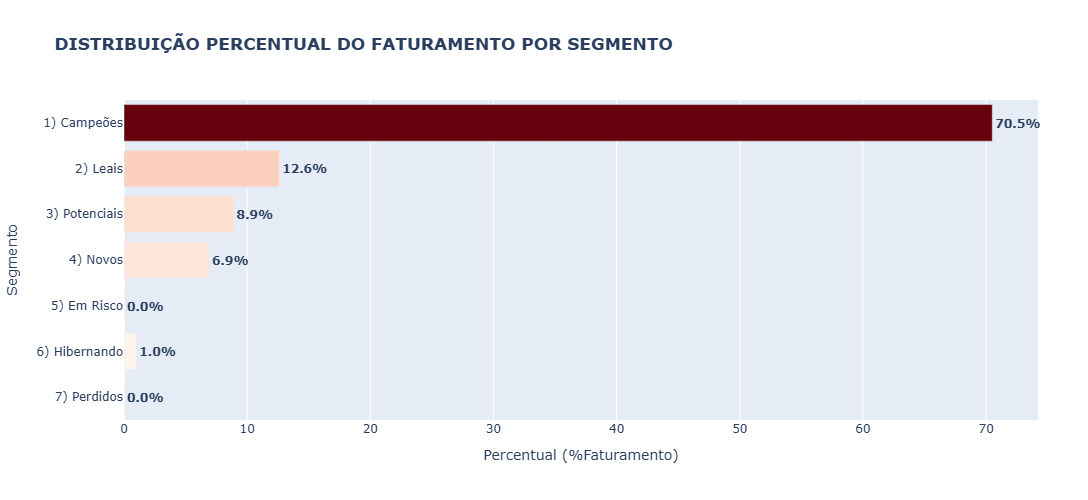

In [35]:
graf_segmento_faturamento

In [57]:
from IPython.display import display, Markdown
display(Markdown("""
#### ANÁLISE DO GRÁFICO: "💰3. ANÁLISE DA PARTICIPAÇÂO DA RECEITA POR PERFIL DE CLIENTE (SEGMENTO RFV)"

- **🏆1."Campeões" (Alta Concentração):** 
    
    **Faturamento** *"Campeões": R$35.5M*

  ***➔ 💡Insight de "Risco" e "Oportunidade":*** *Esses clientes gostam dos produtos e gastam muito. Eles são o motor do negócio. Porém, isso acende um alerta de risco. Se um concorrente conseguir atrair uma parte desse grupo de 5,6%, o faturamento da empresa desaba.*

  ***➔ 🛠Ação:*** *Proteção total a esse grupo. Eles precisam de um atendimento (VIP), canais exclusivos, mimos, antecipação de lançamentos e pesquisas de satisfação constantes (NPS) para garantir que continuem felizes.*

   ---------------------------------------------------------------------------------------------------------------------
- **🤝2.A Validação dos "Leais":** 

     **Faturamento** *"Leais": R$6.3M*

  ***➔ 💡Insight:*** *Os clientes compram com frequência, mas o ticket médio deles é consideravelmente menor do que o dos "Campeões".*

  ***➔ 🛠Ação:*** *Desenvolver estratégias de frete grátis acima de um valor mais alto, planos de assinatura que incentivem esse cliente fiel a gastar um pouco mais.*

   ---------------------------------------------------------------------------------------------------------------------
- **🚀3. Oportunidade de Crescimento ("Potenciais" e "Novos"):**

     **Faturamento** *"Potenciais": R$4.4M*
      
     **Faturamento** *"Novos": R$3.4M*

  ***➔ 💡Insight:*** *A empresa tem um bom resultado em atrair pessoas, mas o primeiro gasto delas ainda é baixo.*

  ***➔ 🛠Ação:*** *Como o faturamento deles ainda é tímido, o foco não é fazer o cliente "Novo" gastar muito de uma vez só, mas sim garantir que ele volte a comprar logo (focar no indicador de Recência e Frequência) para que ele suba de nível.*

   ---------------------------------------------------------------------------------------------------------------------
- **4. Eficiência na "Limpeza" da Base":**
  
    **Faturamento** *"Em Risco": R$358*
  
    **Faturamento** *"Hibernando": R$520K*
  
   **Faturamento** *"Perdidos": R$24K*  

  ***➔ 💡Insight:*** *Isso valida que gastar muito dinheiro tentando recuperar clientes "Perdidos" ou "Hibernando" pode trazer um retorno financeiro muito baixo (ROI ruim).*

  ***➔ 🛠Ação:*** *Não desviar energia ou orçamento de tráfego pago para esses grupos. O melhor investimento é blindando os "Campeões" ou desenvolvendo os "Potenciais".*
 
   ---------------------------------------------------------------------------------------------------------------------
📌 ***Conclusão:*** *A saúde atual do negócio é excelente porque os "Campeões" sustentam o caixa, dando margem e fôlego financeiro para a empresa errar e testar. A estratégia de crescimento da marca agora não deve ser "trazer mais clientes novos a qualquer custo", 
mas sim descobrir o padrão que faz um cliente virar "Campeão" e replicar isso na enorme massa de clientes "Potenciais" que você já tem dentro de casa.*
"""))


#### ANÁLISE DO GRÁFICO: "💰3. ANÁLISE DA PARTICIPAÇÂO DA RECEITA POR PERFIL DE CLIENTE (SEGMENTO RFV)"

- **🏆1."Campeões" (Alta Concentração):** 

    **Faturamento** *"Campeões": R$35.5M*

  ***➔ 💡Insight de "Risco" e "Oportunidade":*** *Esses clientes gostam dos produtos e gastam muito. Eles são o motor do negócio. Porém, isso acende um alerta de risco. Se um concorrente conseguir atrair uma parte desse grupo de 5,6%, o faturamento da empresa desaba.*

  ***➔ 🛠Ação:*** *Proteção total a esse grupo. Eles precisam de um atendimento (VIP), canais exclusivos, mimos, antecipação de lançamentos e pesquisas de satisfação constantes (NPS) para garantir que continuem felizes.*

   ---------------------------------------------------------------------------------------------------------------------
- **🤝2.A Validação dos "Leais":** 

     **Faturamento** *"Leais": R$6.3M*

  ***➔ 💡Insight:*** *Os clientes compram com frequência, mas o ticket médio deles é consideravelmente menor do que o dos "Campeões".*

  ***➔ 🛠Ação:*** *Desenvolver estratégias de frete grátis acima de um valor mais alto, planos de assinatura que incentivem esse cliente fiel a gastar um pouco mais.*

   ---------------------------------------------------------------------------------------------------------------------
- **🚀3. Oportunidade de Crescimento ("Potenciais" e "Novos"):**

     **Faturamento** *"Potenciais": R$4.4M*

     **Faturamento** *"Novos": R$3.4M*

  ***➔ 💡Insight:*** *A empresa tem um bom resultado em atrair pessoas, mas o primeiro gasto delas ainda é baixo.*

  ***➔ 🛠Ação:*** *Como o faturamento deles ainda é tímido, o foco não é fazer o cliente "Novo" gastar muito de uma vez só, mas sim garantir que ele volte a comprar logo (focar no indicador de Recência e Frequência) para que ele suba de nível.*

   ---------------------------------------------------------------------------------------------------------------------
- **4. Eficiência na "Limpeza" da Base":**

    **Faturamento** *"Em Risco": R$358*

    **Faturamento** *"Hibernando": R$520K*

   **Faturamento** *"Perdidos": R$24K*  

  ***➔ 💡Insight:*** *Isso valida que gastar muito dinheiro tentando recuperar clientes "Perdidos" ou "Hibernando" pode trazer um retorno financeiro muito baixo (ROI ruim).*

  ***➔ 🛠Ação:*** *Não desviar energia ou orçamento de tráfego pago para esses grupos. O melhor investimento é blindando os "Campeões" ou desenvolvendo os "Potenciais".*

   ---------------------------------------------------------------------------------------------------------------------
📌 ***Conclusão:*** *A saúde atual do negócio é excelente porque os "Campeões" sustentam o caixa, dando margem e fôlego financeiro para a empresa errar e testar. A estratégia de crescimento da marca agora não deve ser "trazer mais clientes novos a qualquer custo", 
mas sim descobrir o padrão que faz um cliente virar "Campeão" e replicar isso na enorme massa de clientes "Potenciais" que você já tem dentro de casa.*


#### <font color='blue'>🚨4. ANÁLISE SOBRE O ALERTA DE TENDÊNCIAS E CHURN POR SEGMENTO</font>

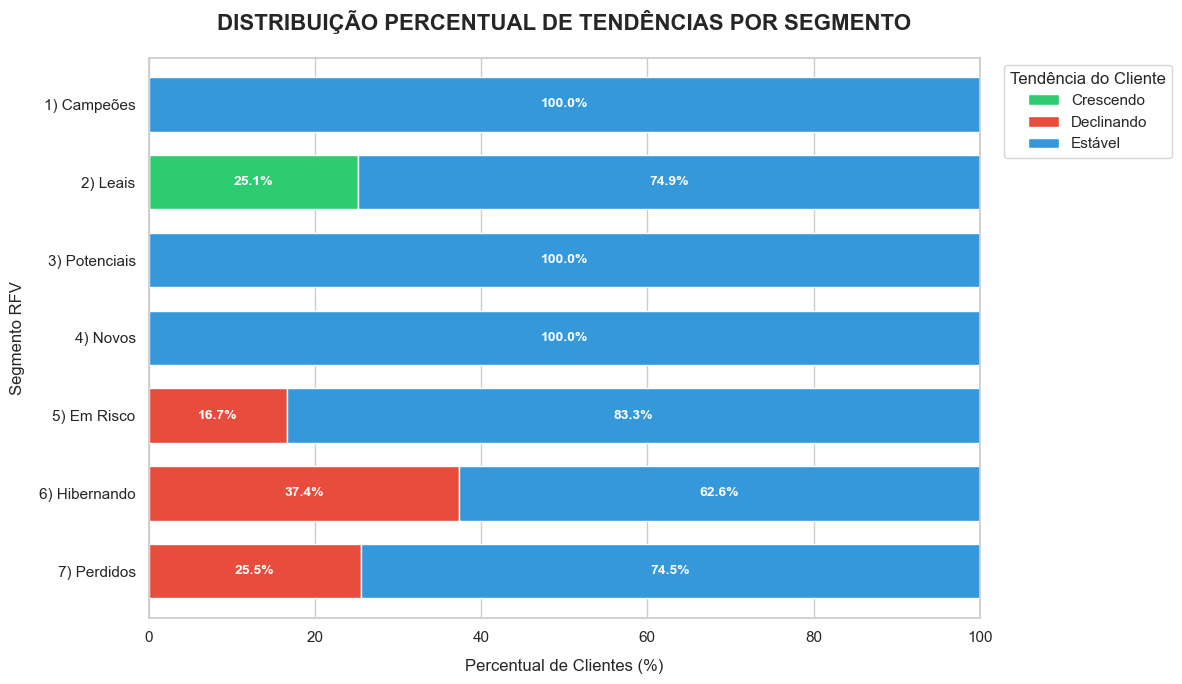

In [47]:
graf_tendencia_cli(rfv_analise)

In [43]:
from IPython.display import display, Markdown
display(Markdown("""
#### ANÁLISE DO GRÁFICO: "🚨4. ANÁLISE SOBRE O ALERTA DE TENDÊNCIAS E CHURN POR SEGMENTO"

- **🏆1. O Segmento "Campeões" está Totalmente Blindado:**

  ***➔ 💡Insight:*** *Sabendo que os "Campeões" representam sozinhos 70,5% do seu faturamento, o fato de estarem 100% estáveis é a melhor notícia possível. 
  Significa que a sua principal fonte de receita é previsível e segura. Não há desengajamento ou perda de ritmo entre os seus clientes mais valiosos.*

  ***➔ 🛠Ação:*** *O foco é a manutenção da experiência. 
  Não mudar drasticamente o produto ou a forma de atendimento oferecido, pois o modelo atual está funcionando perfeitamente. 
  Mantenha as ações de relacionamento VIP e foco em retenção.*

   ---------------------------------------------------------------------------------------------------------------------
- **🚀2. A oportunidade de Novos Campeões está Ativa ("Leais"):**

  ***➔ 💡Insight:*** *O grupo de clientes "Leais" está extremamente saudável. 
  Nenhum deles está reduzindo o ritmo de compra (0% em declínio) e um quarto da base (25,1%) está expandindo seu comportamento de compra (gastando mais ou comprando com mais frequência).*

  ***➔ 🛠Ação:*** *Este grupo é a sua maior oportunidade de crescimento orgânico no curto prazo. 
  Como eles já mostram uma tendência natural de crescimento, aplique estratégias de upsell, kits de maior valor. 
  Eles são os candidatos perfeitos para subir de nível e se tornarem os próximos "Campeões".*

   ---------------------------------------------------------------------------------------------------------------------
- **🆕3. Alta Previsibilidade no Meio do Funil "Potenciais" e "Novos":**

  ***➔ 💡Insight:*** *Juntos, esses dois grupos somam 52,1% do seu volume total de clientes. 
  O fato de estarem 100% estáveis mostra que o comportamento deles pós-aquisição é padronizado e previsível. 
  No entanto, estabilidade absoluta também indica inércia: eles entram, compram o esperado, mas não aceleram por conta própria (0% crescendo).*

  ***➔ 🛠Ação:*** *Como o caixa está seguro graças aos "Campeões", você tem margem para testar gatilhos agressivos de CRM com essa massa de clientes. 
  Crie réguas de comunicação focadas em frequência (ex: "notamos que você gostou do produto X, 
  que tal levar o Y com desconto na sua segunda compra?") para tirá-los da estabilidade e jogá-los para a tendência de crescimento.*

   ---------------------------------------------------------------------------------------------------------------------  
- **🚨4. O Declínio está Restrito a Quem Já Te Traz Pouco Retorno:**

     ***"Em Risco":*** *83,3% Estável | 16,7% Declinando.*
  
     ***"Hibernando":*** *62,6% Estável | 37,4% Declinando.*
  
     ***"Perdidos":*** *74,5% Estável | 25,5% Declinando.*

  ***➔ 💡Insight:*** *É natural e esperado que os segmentos da base do RFV apresentem tendências de declínio. 
  A grande vantagem aqui é que o grosso desses clientes está "Estável" (parado), ou seja, a perda não está acelerando de forma descontrolada. 
  Além disso, como vimos que a soma de "Hibernando" e "Perdidos" gera apenas 1,01% do seu faturamento, o impacto financeiro desse declínio é praticamente irrelevante para o negócio.*

  ***➔ 🛠Ação:*** *Não gaste energia ou orçamento de mídia tentando resgatar esses clientes. 
  Mantenha apenas automações de baixo custo (como e-mails ou mensagens automatizadas de "saudades") e foque os investimentos onde o retorno é real.*

"""))


#### ANÁLISE DO GRÁFICO: "🚨4. ANÁLISE SOBRE O ALERTA DE TENDÊNCIAS E CHURN POR SEGMENTO"

- **🏆1. O Segmento "Campeões" está Totalmente Blindado:**

  ***➔ 💡Insight:*** *Sabendo que os "Campeões" representam sozinhos 70,5% do seu faturamento, o fato de estarem 100% estáveis é a melhor notícia possível. 
  Significa que a sua principal fonte de receita é previsível e segura. Não há desengajamento ou perda de ritmo entre os seus clientes mais valiosos.*

  ***➔ 🛠Ação:*** *O foco é a manutenção da experiência. 
  Não mudar drasticamente o produto ou a forma de atendimento oferecido, pois o modelo atual está funcionando perfeitamente. 
  Mantenha as ações de relacionamento VIP e foco em retenção.*

   ---------------------------------------------------------------------------------------------------------------------
- **🚀2. A oportunidade de Novos Campeões está Ativa ("Leais"):**

  ***➔ 💡Insight:*** *O grupo de clientes "Leais" está extremamente saudável. 
  Nenhum deles está reduzindo o ritmo de compra (0% em declínio) e um quarto da base (25,1%) está expandindo seu comportamento de compra (gastando mais ou comprando com mais frequência).*

  ***➔ 🛠Ação:*** *Este grupo é a sua maior oportunidade de crescimento orgânico no curto prazo. 
  Como eles já mostram uma tendência natural de crescimento, aplique estratégias de upsell, kits de maior valor. 
  Eles são os candidatos perfeitos para subir de nível e se tornarem os próximos "Campeões".*

   ---------------------------------------------------------------------------------------------------------------------
- **🆕3. Alta Previsibilidade no Meio do Funil "Potenciais" e "Novos":**

  ***➔ 💡Insight:*** *Juntos, esses dois grupos somam 52,1% do seu volume total de clientes. 
  O fato de estarem 100% estáveis mostra que o comportamento deles pós-aquisição é padronizado e previsível. 
  No entanto, estabilidade absoluta também indica inércia: eles entram, compram o esperado, mas não aceleram por conta própria (0% crescendo).*

  ***➔ 🛠Ação:*** *Como o caixa está seguro graças aos "Campeões", você tem margem para testar gatilhos agressivos de CRM com essa massa de clientes. 
  Crie réguas de comunicação focadas em frequência (ex: "notamos que você gostou do produto X, 
  que tal levar o Y com desconto na sua segunda compra?") para tirá-los da estabilidade e jogá-los para a tendência de crescimento.*

   ---------------------------------------------------------------------------------------------------------------------  
- **🚨4. O Declínio está Restrito a Quem Já Te Traz Pouco Retorno:**

     ***"Em Risco":*** *83,3% Estável | 16,7% Declinando.*

     ***"Hibernando":*** *62,6% Estável | 37,4% Declinando.*

     ***"Perdidos":*** *74,5% Estável | 25,5% Declinando.*

  ***➔ 💡Insight:*** *É natural e esperado que os segmentos da base do RFV apresentem tendências de declínio. 
  A grande vantagem aqui é que o grosso desses clientes está "Estável" (parado), ou seja, a perda não está acelerando de forma descontrolada. 
  Além disso, como vimos que a soma de "Hibernando" e "Perdidos" gera apenas 1,01% do seu faturamento, o impacto financeiro desse declínio é praticamente irrelevante para o negócio.*

  ***➔ 🛠Ação:*** *Não gaste energia ou orçamento de mídia tentando resgatar esses clientes. 
  Mantenha apenas automações de baixo custo (como e-mails ou mensagens automatizadas de "saudades") e foque os investimentos onde o retorno é real.*



#### <font color='blue'>📊5. ANÁLISE SOBRE O NÍVEL DE ENGAJAMENTO POR SEGMENTO DE CLIENTES</font>

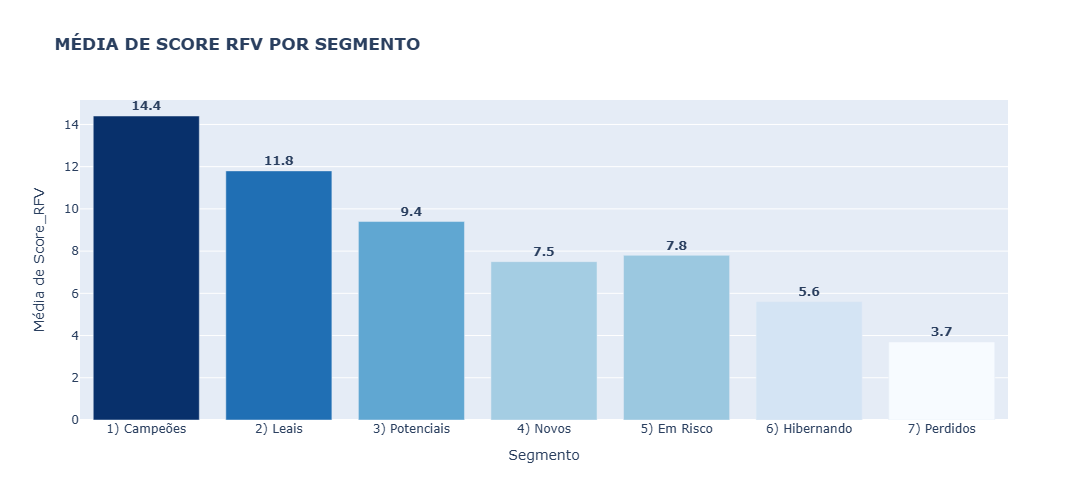

In [43]:
graf_media_score_cli

In [54]:
from IPython.display import display, Markdown
display(Markdown("""
#### ANÁLISE DO GRÁFICO: "📊5. ANÁLISE SOBRE O NÍVEL DE ENGAJAMENTO POR SEGMENTO DE CLIENTES"

- **1. Validação Técnica do Modelo:**

  ***➔ 💡Insight:*** *A transição suave e decrescente entre as médias comprova que o seu algoritmo de segmentação separa os clientes com precisão. 
  Não há sobreposição estranha (como um cliente "Novo" ter score maior que um "Potencial"). A base organizada.*

 ---------------------------------------------------------------------------------------------------------------------
- **2. O Desafio do Score 10:**

   ***➔ 💡Insight:*** *A barreira que separa um cliente promissor ("Potencial") de um cliente verdadeiramente fiel ("Leal") está na casa dos 10 a 11 pontos. 
   Como o grupo de "Potenciais" tem uma média alta (9,4), significa que muitos deles estão "na trave", precisando de muito pouco para subir de nível.*

   ***➔ 🛠Ação CRM:*** *Identifique no banco de dados quais clientes Potenciais têm score entre 9,5 e 10. 
   Eles são o seu alvo mais fácil! Às vezes, apenas uma compra a mais (Frequência) 
   ou um pedido com valor um pouco maior (Valor) vai dar os 1 ou 2 pontos que faltam para eles virarem "Leais".*

 ---------------------------------------------------------------------------------------------------------------------
  - **3. Alerta do Score 7,5:**

    ***➔ 💡Insight:*** *Esse empate matemático é fascinante para o negócio. 
    Ele mostra que o score 7,5 é o "ponto de equilíbrio" da sua base, mas com direções opostas:*

    *O cliente "Novo" (7,5) tem esse score porque acabou de chegar. 
    Ele tem Recência máxima, mas Frequência e Valor baixos, está olhando para a frente (fase de expansão).*

    *O cliente "Em Risco" (7,5) tem esse score porque está derretendo. Ele já teve Frequência e Valor altos no passado, 
    mas a sua Recência está caindo (faz tempo que não compra). Ele está olhando para trás (fase de retração).*

    ***➔ 🛠Ação:*** *O tratamento para o score 7,5 deve ser dividido. Para o "Novo", o foco é o incentivo à segunda compra. 
    Para o "Em Risco", o foco é o resgate imediato (uma oferta de "sentimos sua falta") antes que o score dele caia para a casa dos 5 pontos ("Hibernando").*

 ---------------------------------------------------------------------------------------------------------------------
  - **4. A Zona de Desengajamento (Abaixo de 6):**

    ***➔ 💡Insight:*** *Quando o score de um cliente cai abaixo de 6, ele entra na zona de "esfriamento crítico". 
    O score 3,7 dos "Perdidos" mostra que eles zeraram quase todos os critérios do seu RFV (provavelmente só têm alguma nota em Valor Monetário pelo que gastaram no passado, mas Recência e Frequência zeraram).*

    ***➔ 🛠Ação:*** *Isso reforça o insight dos gráficos anteriores, recuperar clientes com score abaixo de 6 exige um esforço computacional e de marketing que dificilmente se paga, já que a saúde matemática deles está muito deteriorada.*
"""))


#### ANÁLISE DO GRÁFICO: "📊5. ANÁLISE SOBRE O NÍVEL DE ENGAJAMENTO POR SEGMENTO DE CLIENTES"

- **1. Validação Técnica do Modelo:**

  ***➔ 💡Insight:*** *A transição suave e decrescente entre as médias comprova que o seu algoritmo de segmentação separa os clientes com precisão. 
  Não há sobreposição estranha (como um cliente "Novo" ter score maior que um "Potencial"). A base organizada.*

 ---------------------------------------------------------------------------------------------------------------------
- **2. O Desafio do Score 10:**

   ***➔ 💡Insight:*** *A barreira que separa um cliente promissor ("Potencial") de um cliente verdadeiramente fiel ("Leal") está na casa dos 10 a 11 pontos. 
   Como o grupo de "Potenciais" tem uma média alta (9,4), significa que muitos deles estão "na trave", precisando de muito pouco para subir de nível.*

   ***➔ 🛠Ação CRM:*** *Identifique no banco de dados quais clientes Potenciais têm score entre 9,5 e 10. 
   Eles são o seu alvo mais fácil! Às vezes, apenas uma compra a mais (Frequência) 
   ou um pedido com valor um pouco maior (Valor) vai dar os 1 ou 2 pontos que faltam para eles virarem "Leais".*

 ---------------------------------------------------------------------------------------------------------------------
  - **3. Alerta do Score 7,5:**

    ***➔ 💡Insight:*** *Esse empate matemático é fascinante para o negócio. 
    Ele mostra que o score 7,5 é o "ponto de equilíbrio" da sua base, mas com direções opostas:*

    *O cliente "Novo" (7,5) tem esse score porque acabou de chegar. 
    Ele tem Recência máxima, mas Frequência e Valor baixos, está olhando para a frente (fase de expansão).*

    *O cliente "Em Risco" (7,5) tem esse score porque está derretendo. Ele já teve Frequência e Valor altos no passado, 
    mas a sua Recência está caindo (faz tempo que não compra). Ele está olhando para trás (fase de retração).*

    ***➔ 🛠Ação:*** *O tratamento para o score 7,5 deve ser dividido. Para o "Novo", o foco é o incentivo à segunda compra. 
    Para o "Em Risco", o foco é o resgate imediato (uma oferta de "sentimos sua falta") antes que o score dele caia para a casa dos 5 pontos ("Hibernando").*

 ---------------------------------------------------------------------------------------------------------------------
  - **4. A Zona de Desengajamento (Abaixo de 6):**

    ***➔ 💡Insight:*** *Quando o score de um cliente cai abaixo de 6, ele entra na zona de "esfriamento crítico". 
    O score 3,7 dos "Perdidos" mostra que eles zeraram quase todos os critérios do seu RFV (provavelmente só têm alguma nota em Valor Monetário pelo que gastaram no passado, mas Recência e Frequência zeraram).*

    ***➔ 🛠Ação:*** *Isso reforça o insight dos gráficos anteriores, recuperar clientes com score abaixo de 6 exige um esforço computacional e de marketing que dificilmente se paga, já que a saúde matemática deles está muito deteriorada.*
